In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm
from scipy.interpolate import make_smoothing_spline
from sklearn.metrics import r2_score

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

import imageio
import os
import shutil

# Multiple simulations analysis

## Functions

In [8]:
def read_file(fname, thr_len=0):
    data = []
    with open(fname) as f:
        for x in f:
            line = np.array([float(n) for n in x.split(", ")])
            if len(line)>thr_len:
                data.append(line)
    return data

def normalize(c,r,mu,mI,mO,mS,mHK,mu0,r0):
    mu_c = [np.array([(m-mu0*(1-t))/t for (m,t) in zip(mu[i],c[i])]) for i in range(len(c))]
    r_c = [np.array([(m-r0*(1-t))/t for (m,t) in zip(r[i],c[i])]) for i in range(len(c))]
    mI_c = [np.array([(m*(1-t))/t for (m,t) in zip(mI[i],c[i])]) for i in range(len(c))]
    mO_c = [np.array([(m*(1-t))/t for (m,t) in zip(mO[i],c[i])]) for i in range(len(c))]
    mS_c = [np.array([(m*(1-t))/t for (m,t) in zip(mS[i],c[i])]) for i in range(len(c))]
    mHK_c = [np.array([(m*(1-t))/t for (m,t) in zip(mHK[i],c[i])]) for i in range(len(c))]
    return r_c,mu_c,mI_c,mO_c,mS_c,mHK_c


### Error areas x ###
def return_stats(vec, interv):
    means =[]
    stds = []
    for i in range(len(interv)-1):
        provv = []
        for j in range(len(vec)):
            provv.append(np.where(np.logical_and(vec[j]>interv[i],vec[j]<=interv[i+1]))[0])
        provv = np.concatenate(provv)
        means.append(np.mean(provv))
        stds.append(np.std(provv))
    
    return np.array(means), np.array(stds)

def reconstruct_ymean(mm, space):
    x = []
    for i in range(int(max(mm))):
        p0 = np.where(mm<=i)[0][-1]
        p1 = np.where(mm>i)[0][0]
        slope = space/(mm[p1]-mm[p0])
        x.append(interv_0[p0]+slope*1)
    return np.array(x)

def running_slope(x, skip):
    vec = []
    for i in range(skip, len(x)-skip-1):
        vec.append((x[i+skip]-x[i])/skip)
    return np.array(vec)


### Error areas y ###
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = np.empty(n, dtype=float)
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = arr.mean()
            stds[i] = arr.std(ddof=0)  # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds[i] = np.nan
            
    return means, stds

def plot_stats_elementwise(x, ax, label="", color="C0", lw=3, alpha=0.3):
    means, stds = stats_elementwise(x)
    ci_half_width = stds
    
    ax.plot(np.arange(len(means)), means, color=color, lw=lw, label=label)
    ax.fill_between(np.arange(len(means)) ,means-stds, means+stds, color=color, alpha=alpha)

## Load Data

In [14]:
### Polyploid case ###
rs_12 = read_file("../Data/CancerEvo/12ch_r.txt")
ms_12 = read_file("../Data/CancerEvo/12ch_m.txt")
mus_12 = read_file("../Data/CancerEvo/12ch_mu.txt")
ts_12 = read_file("../Data/CancerEvo/12ch_t.txt")
ng_12 = read_file("../Data/CancerEvo/12ch_nc.txt")
ss_12 = np.loadtxt("../Data/CancerEvo/12ch_state.txt", dtype=str)
ls_12 = np.array([len(r) for r in rs_12])
map_h_12 = ss_12=="Health"
map_t_12 = ss_12=="Tumor"
    # Tumor wins runs quantities
mus_t_12 = [mus_12[i] for i in np.where(map_t_12)[0]]
rs_t_12 = [rs_12[i] for i in np.where(map_t_12)[0]]
ms_t_12 = [ms_12[i] for i in np.where(map_t_12)[0]]
ts_t_12 = [ts_12[i] for i in np.where(map_t_12)[0]]
ng_t_12 = [ng_12[i] for i in np.where(map_t_12)[0]]

In [15]:
# READ DATA #

### Diploid case ###
rs_0 = read_file("../Data/CancerEvo/0ch_r.txt")
mus_0 = read_file("../Data/CancerEvo/0ch_mu.txt")
ks_0 = read_file("../Data/CancerEvo/0ch_k.txt")
ts_0 = read_file("../Data/CancerEvo/0ch_t.txt")
ss_0 = np.loadtxt("../Data/CancerEvo/0ch_state.txt", dtype=str)
ls_0 = np.array([len(r) for r in rs_0])
map_h_0 = ss_0=="Health"
map_t_0 = ss_0=="Tumor"
    # Tumor wins runs quantities
mus_t_0 = [mus_0[i] for i in np.where(map_t_0)[0]]
rs_t_0 = [rs_0[i] for i in np.where(map_t_0)[0]]
ts_t_0 = [ts_0[i] for i in np.where(map_t_0)[0]]

### Polyploid case ###
rs_1 = read_file("../Data/CancerEvo/1ch_r.txt")
mus_1 = read_file("../Data/CancerEvo/1ch_mu.txt")
ts_1 = read_file("../Data/CancerEvo/1ch_t.txt")
ng_1 = read_file("../Data/CancerEvo/1ch_nc.txt")
aM_1 = read_file("../Data/CancerEvo/1ch_aM.txt")
ss_1 = np.loadtxt("../Data/CancerEvo/1ch_state.txt", dtype=str)
ls_1 = np.array([len(r) for r in rs_1])
map_h_1 = ss_1=="Health"
map_t_1 = ss_1=="Tumor"
    # Tumor wins runs quantities
mus_t_1 = [mus_1[i] for i in np.where(map_t_1)[0]]
rs_t_1 = [rs_1[i] for i in np.where(map_t_1)[0]]
ts_t_1 = [ts_1[i] for i in np.where(map_t_1)[0]]
ng_t_1 = [ng_1[i] for i in np.where(map_t_1)[0]]
#aM_t_1 = [aM_1[i] for i in np.where(map_t_1)[0]]

### Aneuploid case ###
rs_2 = read_file("../Data/CancerEvo/2ch_r.txt")
mus_2 = read_file("../Data/CancerEvo/2ch_mu.txt")
ts_2 = read_file("../Data/CancerEvo/2ch_t.txt")[-len(rs_2):]
aI_2 = read_file("../Data/CancerEvo/2ch_aI.txt")
aO_2 = read_file("../Data/CancerEvo/2ch_aO.txt")
aS_2 = read_file("../Data/CancerEvo/2ch_aS.txt")
aM_2 = read_file("../Data/CancerEvo/2ch_aM.txt")
nI_2 = read_file("../Data/CancerEvo/2ch_nI.txt")
nO_2 = read_file("../Data/CancerEvo/2ch_nO.txt")
nS_2 = read_file("../Data/CancerEvo/2ch_nS.txt")
nM_2 = read_file("../Data/CancerEvo/2ch_nM.txt")
nHK_2 = read_file("../Data/CancerEvo/2ch_nHK.txt")
#aHK_2 = read_file("../Data/CancerEvo/2ch_aHK.txt")
ss_2 = np.loadtxt("../Data/CancerEvo/2ch_state.txt", dtype=str)
ls_2 = np.array([len(r) for r in rs_2])
map_h_2 = ss_2=="Health"
map_t_2 = ss_2=="Tumor"
    # Tumor wins runs quantities
mus_t_2 = [mus_2[i] for i in np.where(map_t_2)[0]]
rs_t_2 = [rs_2[i] for i in np.where(map_t_2)[0]]
ts_t_2 = [ts_2[i] for i in np.where(map_t_2)[0]]
aI_t_2 = [aI_2[i] for i in np.where(map_t_2)[0]]
aO_t_2 = [aO_2[i] for i in np.where(map_t_2)[0]]
aS_t_2 = [aS_2[i] for i in np.where(map_t_2)[0]]
aM_t_2 = [aM_2[i] for i in np.where(map_t_2)[0]]
nI_t_2 = [nI_2[i] for i in np.where(map_t_2)[0]]
nO_t_2 = [nO_2[i] for i in np.where(map_t_2)[0]]
nS_t_2 = [nS_2[i] for i in np.where(map_t_2)[0]]
nM_t_2 = [nM_2[i] for i in np.where(map_t_2)[0]]
nHK_t_2 = [nHK_2[i] for i in np.where(map_t_2)[0]]

## Analysis

In [10]:
print(r"Probability tumor Diploid = %.2f" %(sum(map_t_0)/(sum(map_h_0)+sum(map_t_0))))
print(r"Probability tumor Polyploid = %.2f" %(sum(map_t_1)/(sum(map_h_1)+sum(map_t_1))))
print(r"Probability tumor Aneuploid = %.2f" %(sum(map_t_2)/(sum(map_h_2)+sum(map_t_2))))

Probability tumor Diploid = 0.28
Probability tumor Polyploid = 0.25
Probability tumor Aneuploid = 0.36


In [11]:
colors_gene_type = {"I":"deepskyblue", "O":"darkorange", "S":"forestgreen", "M":"darkorchid", "HK":"gold"}
colors_ploid = {"di":"orangered", "poli":"purple", "aneu":"forestgreen", "5n":"red"}

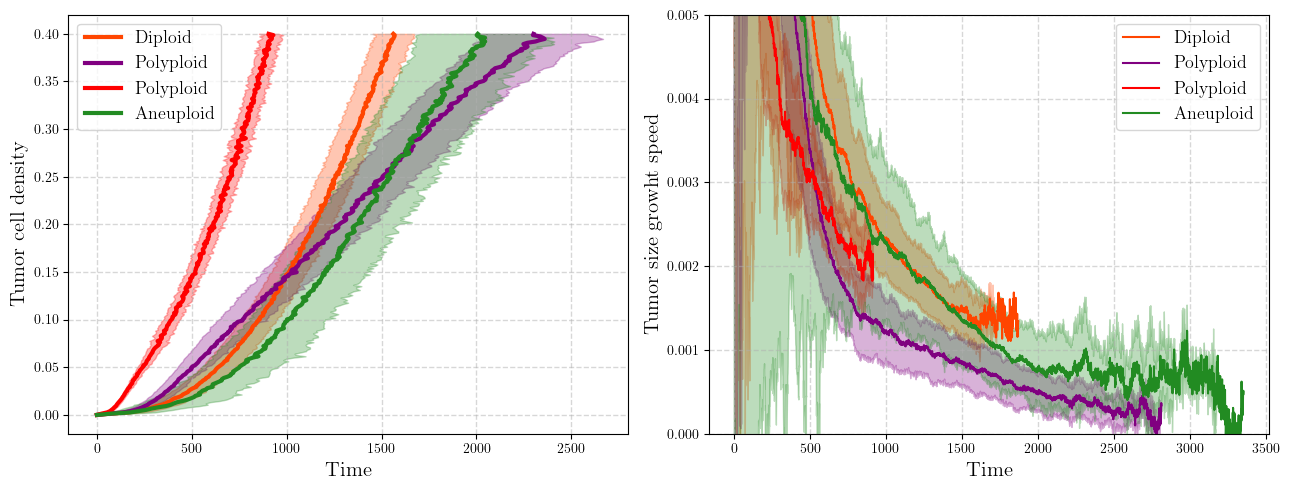

In [12]:
### Comparison diploid, aneuploid, polyploid ###
################################################

_, ax = plt.subplots(1,2,figsize=(13,5))


### TUMOR SIZE ###
interv_0 = np.linspace(0,0.4,300)
means_0, stds_0 = return_stats(ts_t_0,interv_0)
means_0 = np.concatenate([[0], means_0])
stds_0 = np.concatenate([[0], stds_0])
ci_half_width = stds_0

ax[0].plot(means_0, interv_0, color=colors_ploid["di"], lw=3, label="Diploid")
ax[0].fill_betweenx(interv_0,means_0-stds_0, means_0+stds_0, alpha=0.3,color=colors_ploid["di"])

interv_1 = np.linspace(0,0.4,300)
means_1, stds_1 = return_stats(ts_t_1,interv_1)
means_1 = np.concatenate([[0], means_1])
stds_1 = np.concatenate([[0], stds_1])
ci_half_width = stds_1

ax[0].plot(means_1, interv_1, color=colors_ploid["poli"], lw=3, label="Polyploid")
ax[0].fill_betweenx(interv_1, means_1-stds_1, means_1+stds_1, color=colors_ploid["poli"], alpha=0.3)

interv_12 = np.linspace(0,0.4,300)
means_12, stds_12 = return_stats(ts_t_12,interv_12)
means_12 = np.concatenate([[0], means_12])
stds_12 = np.concatenate([[0], stds_12])
ci_half_width = stds_12

ax[0].plot(means_12, interv_12, color=colors_ploid["5n"], lw=3, label="Polyploid")
ax[0].fill_betweenx(interv_12, means_12-stds_12, means_12+stds_12, color=colors_ploid["5n"], alpha=0.3)

interv_2 = np.linspace(0,0.4,300)
means_2, stds_2 = return_stats(ts_t_2,interv_2)
means_2 = np.concatenate([[0], means_2])
stds_2 = np.concatenate([[0], stds_2])
ci_half_width = stds_2

ax[0].plot(means_2, interv_2, color=colors_ploid["aneu"], lw=3, label="Aneuploid")
ax[0].fill_betweenx(interv_2, means_2-stds_2, means_2+stds_2, color=colors_ploid["aneu"], alpha=0.3)

ax[0].legend(fontsize=13)
ax[0].grid(ls="--", lw=1, alpha=0.5)
ax[0].set_xlabel("Time", fontsize=15)
ax[0].set_ylabel("Tumor cell density", fontsize=15)
#ax[0].set_xticks(fontsize=12)
#ax[0].set_yticks(fontsize=12)

### MUTATION RATE ###
means_mu_0, stds_0 = stats_elementwise(mus_t_0)
ci_half_width = stds_0

#ax[1].plot(np.arange(len(means_mu_0)), means_mu_0, color='orangered', lw=3, label="Diploid")
#ax[1].fill_between(np.arange(len(means_mu_0)) ,means_mu_0-stds_0, means_mu_0+stds_0, alpha=0.3,color='orangered')

#means_mu_1, stds_1 = stats_elementwise(mus_t_1)
#ci_half_width = stds_1

#ax[1].plot(np.arange(len(means_mu_1)), means_mu_1, color='purple', lw=3, label="Polyploid")
#ax[1].fill_between(np.arange(len(means_mu_1)) ,means_mu_1-stds_1, means_mu_1+stds_1, color='purple', alpha=0.3)

#means_mu_2, stds_2 = stats_elementwise(mus_t_2)
#ci_half_width = stds_2

#ax[1].plot(np.arange(len(means_mu_2)), means_mu_2, color='forestgreen', lw=3, label="Aneuploid")
#ax[1].fill_between(np.arange(len(means_mu_2)) ,means_mu_2-stds_2, means_mu_2+stds_2, color='forestgreen', alpha=0.3)
skip=50

plot_stats_elementwise([running_slope(t, skip)/t[skip+1:-skip] for t in ts_t_0], ax[1], color=colors_ploid["di"], lw=1.5, label="Diploid")
plot_stats_elementwise([running_slope(t, skip)/t[skip+1:-skip] for t in ts_t_1], ax[1], color=colors_ploid["poli"], lw=1.5, label="Polyploid")
plot_stats_elementwise([running_slope(t, skip)/t[skip+1:-skip] for t in ts_t_12], ax[1], color=colors_ploid["5n"], lw=1.5, label="Polyploid")
plot_stats_elementwise([running_slope(t, skip)/t[skip+1:-skip] for t in ts_t_2], ax[1], color=colors_ploid["aneu"][:2500], lw=1.5, label="Aneuploid")

ax[1].set_ylim([0,0.005])
ax[1].legend(fontsize=13)
ax[1].grid(ls="--", lw=1, alpha=0.5)
ax[1].set_xlabel("Time", fontsize=15)
ax[1].set_ylabel("Tumor size growht speed", fontsize=15)
    
plt.tight_layout()
#plt.savefig("images/tumorgrowths.png")

In [13]:
def slopes(vec, skip):
    slopes = []
    for i in range(skip,len(vec)-skip):
        slopes.append(np.polyfit(np.arange(skip), vec[i:i+skip], deg=1)[0])
    return np.array(slopes)

NameError: name 'space' is not defined

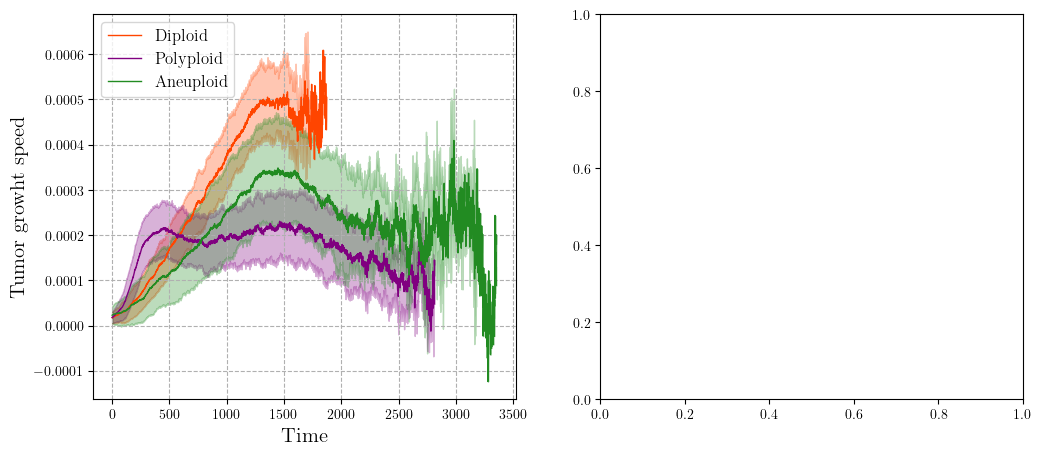

In [14]:
### Comparison growth speed ###
skip=50
_, ax = plt.subplots(1,2,figsize=(12,5))
plot_stats_elementwise([running_slope(t, skip) for t in ts_t_0], ax[0], color=colors_ploid["di"], lw=1, label="Diploid")
plot_stats_elementwise([running_slope(t, skip) for t in ts_t_1], ax[0], color=colors_ploid["poli"], lw=1, label="Polyploid")
plot_stats_elementwise([running_slope(t, skip) for t in ts_t_2], ax[0], color=colors_ploid["aneu"], lw=1, label="Aneuploid")

ax[0].legend(fontsize=12)
ax[0].grid(ls="--")
ax[0].set_xlabel("Time", fontsize=15)
ax[0].set_ylabel("Tumor growht speed", fontsize=15)

ax[1].plot(running_slope(reconstruct_ymean(means_0, space), 100), color=colors_ploid["di"], lw=2, label="Diploid")
ax[1].plot(running_slope(reconstruct_ymean(means_1, space), 100), color=colors_ploid["poli"], lw=2, label="Polyploid")
ax[1].plot(running_slope(reconstruct_ymean(means_2, space), 150), color=colors_ploid["aneu"], lw=2, label="Aneuploid")

ax[1].legend(fontsize=12)
ax[1].grid(ls="--")
ax[1].set_xlabel("Time", fontsize=15)
ax[1].set_ylabel("Tumor growht speed", fontsize=15)

plt.tight_layout()

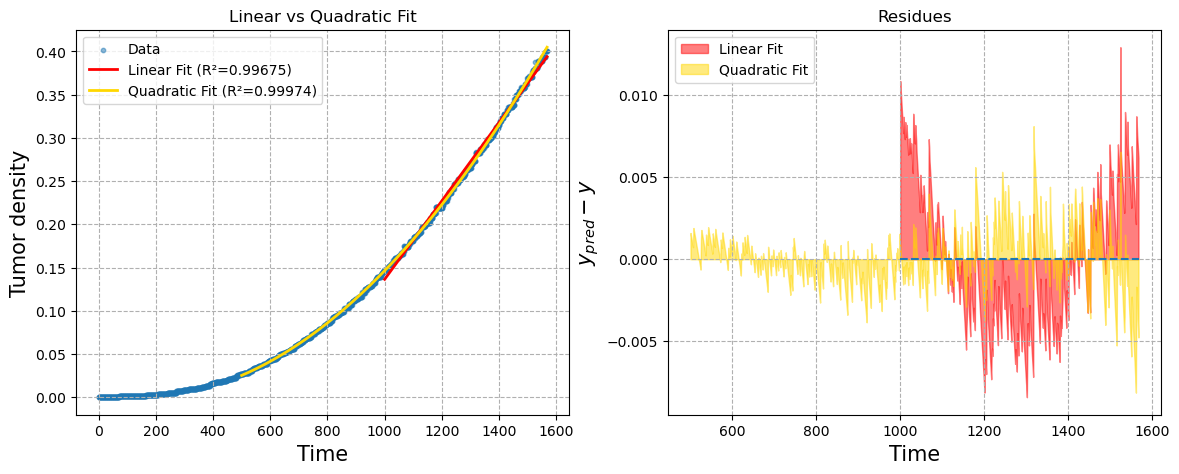

Linear coefficients: [ 0.00045347 -0.31706469]
Quadratic coefficients: [ 1.99310318e-07 -5.66684903e-05  3.74977641e-03]
Linear R²: 0.9968
Quadratic R²: 0.9997


In [ ]:
### Linear vs Quadratic trend ###

# Sample data
y = reconstruct_ymean(means_0, space)
x = np.arange(len(y))

# Fit linear model (degree 1)
coeffs_linear = np.polyfit(x[1000:], y[1000:], deg=1)
y_pred_linear = np.polyval(coeffs_linear, x[1000:])

# Fit quadratic model (degree 2)
coeffs_quad = np.polyfit(x[500:], y[500:], deg=2)
y_pred_quad = np.polyval(coeffs_quad, x[500:])

# Compute R² for both fits
r2_linear = r2_score(y[1000:], y_pred_linear)
r2_quad = r2_score(y[500:], y_pred_quad)

# Plot
_,ax = plt.subplots(1,2,figsize=(14,5))
ax[0].scatter(x, y, label='Data', alpha=0.5, s=10)
ax[0].plot(x[1000:], y_pred_linear, label=f'Linear Fit (R²={r2_linear:.5f})', color="red", lw=2)
ax[0].plot(x[500:], y_pred_quad, label=f'Quadratic Fit (R²={r2_quad:.5f})', color="gold", lw=2)
ax[0].legend()
ax[0].set_title('Linear vs Quadratic Fit')
ax[0].set_xlabel('Time', fontsize=15)
ax[0].set_ylabel('Tumor density', fontsize=15)
ax[0].grid(ls="--")

ax[1].fill_between(x[1000:], 0, y[1000:]-y_pred_linear, label='Linear Fit', color="red", alpha=0.5)
ax[1].fill_between(x[500:], 0, y[500:]-y_pred_quad, label='Quadratic Fit', color="gold", alpha=0.5)
ax[1].hlines(0,1000,len(y), ls="--")
ax[1].legend()
ax[1].set_title('Residues')
ax[1].set_xlabel('Time', fontsize=15)
ax[1].set_ylabel(r'$y_{pred}-y$', fontsize=15)
ax[1].grid(ls="--")

plt.show()

# Print fit comparison
print("Linear coefficients:", coeffs_linear)
print("Quadratic coefficients:", coeffs_quad)
print(f"Linear R²: {r2_linear:.4f}")
print(f"Quadratic R²: {r2_quad:.4f}")


# Analytics

## Phase diagram

In [9]:
def dyn_state(r,r0,mu,k,N):
    return r/r0, (1-(1-mu)**(2*k*N)*(1-mu**2)**(N*(1-2*k)))

In [10]:
### Data on phase diagram ###

r_prop_list = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])
results = np.array([-0.6101874390439277, 0.6226682669930774, 1.2917773010287472, 1.8387745389776091, 2.2434712898547584, 2.660774128739252, 2.9356429157955044, 3.1821620335205547, 3.4130647650803505, 3.625270864316522, 3.8084414875435573])
p_die_data = np.array([(1-(1-m*1e-2)**(10)) for m in results])

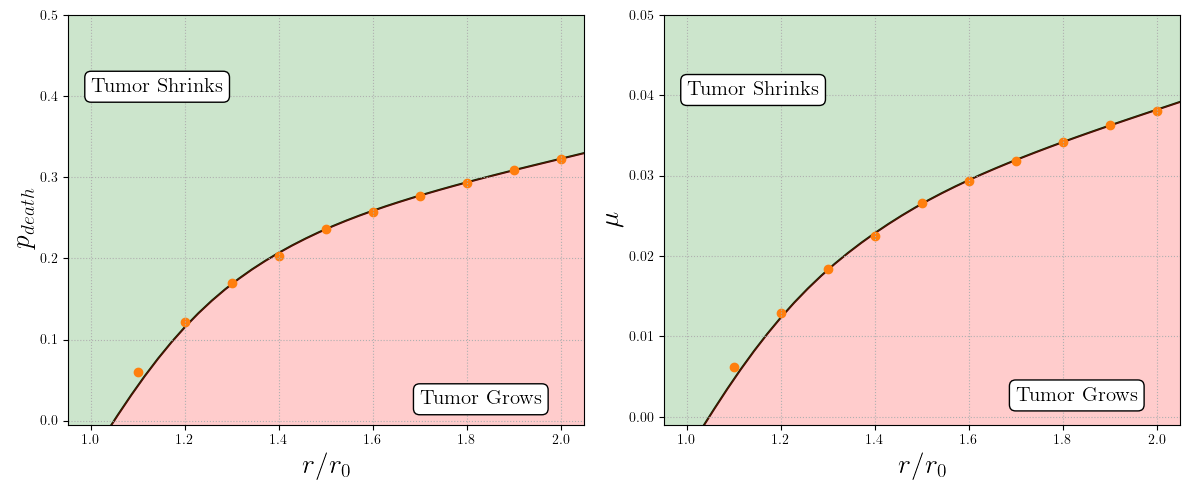

In [11]:
#### PHASE DIAGRAM PLOT ####
############################

r0=2e-1
N=10
_,ax = plt.subplots(1,2,figsize=(12,5))

spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[0].scatter(r_prop_list, p_die_data, color="C1")

spl = make_smoothing_spline(r_prop_list, results*1e-2, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[1].plot(x_new, spl(x_new), color="k", zorder=0)
ax[1].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[1].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[1].scatter(r_prop_list, results*1e-2, color="C1")

[axi.set_xlabel(r"$r/r_0$", fontsize=20) for axi in ax]
[axi.set_xlim([0.95,2.05]) for axi in ax]
ax[0].set_ylim([-0.005,0.5])
ax[1].set_ylim([-0.001,0.05])
ax[0].text(1,0.405,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[1].text(1,0.04,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[1].text(1.7,0.002,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].set_ylabel(r"$p_{death}$", fontsize=20)
ax[1].set_ylabel(r"$\mu$", fontsize=20)

#plt.legend()
[axi.grid(ls=":") for axi in ax]
plt.tight_layout()

In [21]:
#### Load Data ####
###################
#4
idx_h = np.where(np.all([np.array([len(m) for m in mus_0]) > 200, ss_0=="Health"], axis=0))[0][4]
idx_t = np.where(np.all([np.array([len(m) for m in mus_0]) > 200, ss_0=="Tumor"], axis=0))[0][0]

# Recovery case
rs_h = read_file("../Data/CancerEvo/0ch_r.txt")[idx_h]
mus_h = read_file("../Data/CancerEvo/0ch_mu.txt")[idx_h]
k_h = read_file("../Data/CancerEvo/0ch_k.txt")[idx_h]
t_h = read_file("../Data/CancerEvo/0ch_t.txt")[idx_h]

# Proliferation case
rs_t = read_file("../Data/CancerEvo/0ch_r.txt")[idx_t]
mus_t = read_file("../Data/CancerEvo/0ch_mu.txt")[idx_t]
k_t = read_file("../Data/CancerEvo/0ch_k.txt")[idx_t]
t_t = read_file("../Data/CancerEvo/0ch_t.txt")[idx_t]

N_chr = 2
r0 = 1.5e-1
N_HK = 10

savefig = False
namefig = "../CancerEvo/images/fig3_health_1.png"

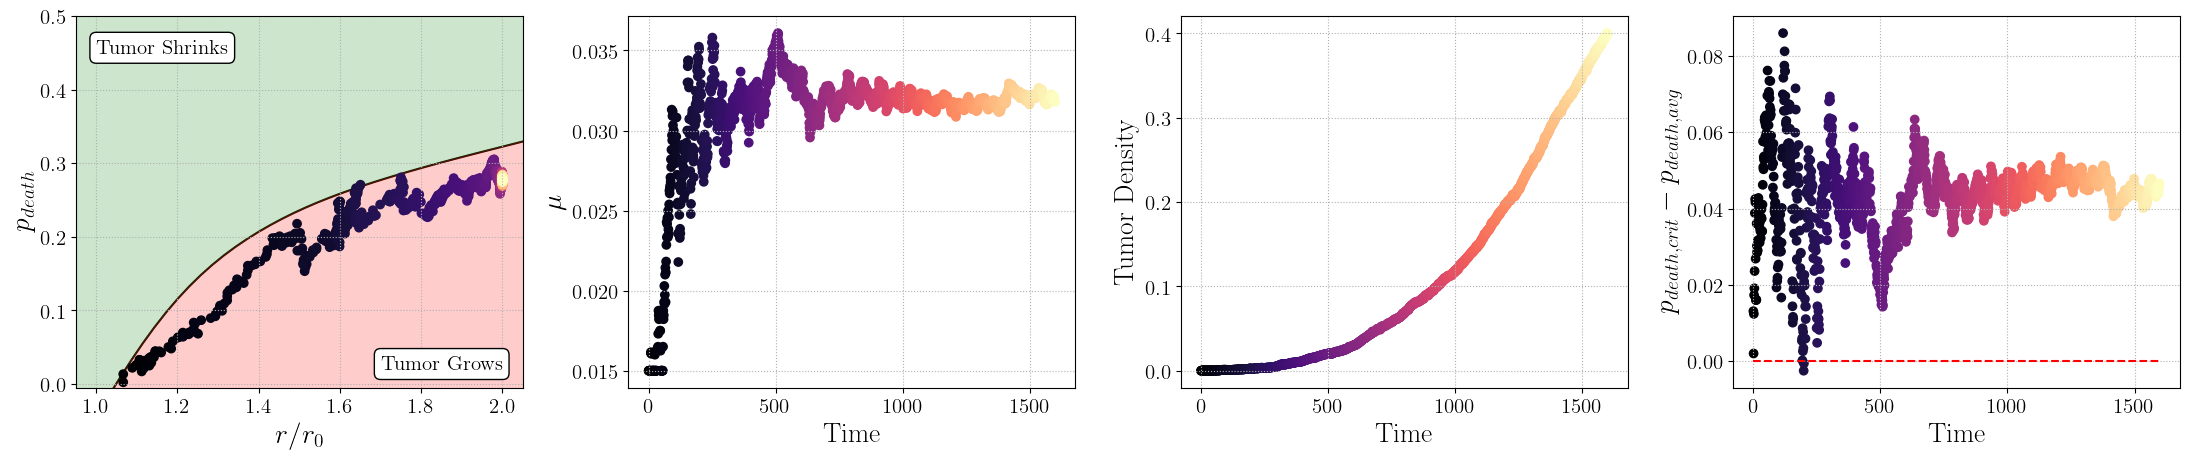

In [25]:
_,ax = plt.subplots(1,4,figsize=(22,4.7))
ax = ax.flatten()
fontsize = 20
[axi.tick_params(axis='both', which='major', labelsize=15) for axi in ax]
[axi.grid(ls=":") for axi in ax]

# phase space graph
spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
points_t = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N_HK) for r,mu,k in zip(rs_t,mus_t,k_t)])
ax[0].scatter(*points_t.T, c=np.linspace(0,1,len(points_t)), cmap="magma", label="Tumor")
ax[0].set_xlabel(r"$r/r_0$", fontsize=fontsize)
ax[0].set_ylabel(r"$p_{death}$", fontsize=fontsize)
ax[0].set_xlim([0.95,2.05])
ax[0].set_ylim([-0.005,0.5])
ax[0].text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
# mutation rate
ax[1].scatter(np.arange(len(mus_t)), mus_t, c=np.arange(len(t_t)), cmap="magma", zorder=0)
ax[1].set_xlabel("Time", fontsize=fontsize)
ax[1].set_ylabel(r"$\mu$", fontsize=fontsize)
# tumor size
ax[2].scatter(np.arange(len(t_t)), t_t, c=np.arange(len(t_t)), cmap="magma", zorder=0)
ax[2].set_xlabel("Time", fontsize=fontsize)
ax[2].set_ylabel("Tumor Density", fontsize=fontsize)
# distance critical line
ax[3].scatter(np.arange(len(t_t)), [spl(rsi/r0)-p_d for rsi,p_d in zip(rs_t, points_t[:,1])], c=np.arange(len(t_t)), cmap="magma", zorder=0)
ax[3].hlines(0,0,len(t_t), color="red", ls="--")
ax[3].set_xlabel("Time", fontsize=fontsize)
ax[3].set_ylabel(r"$p_{death,crit}-p_{death,avg}$", fontsize=fontsize)

plt.tight_layout()
if savefig:
    plt.savefig(namefig)

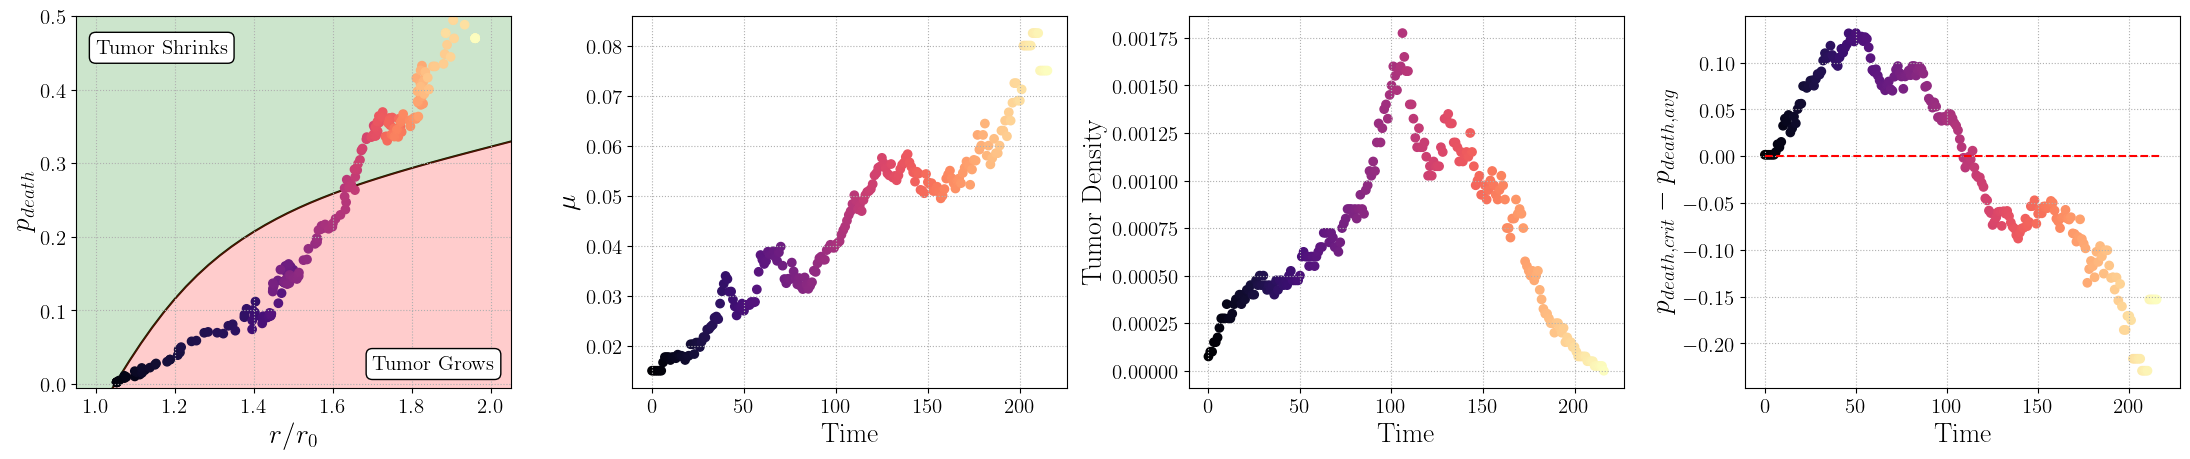

In [26]:
_,ax = plt.subplots(1,4,figsize=(22,4.7))
ax = ax.flatten()
fontsize = 20
[axi.tick_params(axis='both', which='major', labelsize=15) for axi in ax]
[axi.grid(ls=":") for axi in ax]

# phase space graph
spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
points_h = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N_HK) for r,mu,k in zip(rs_h,mus_h,k_h)])
ax[0].scatter(*points_h.T, c=np.linspace(0,1,len(points_h)), cmap="magma", label="Tumor")
ax[0].set_xlabel(r"$r/r_0$", fontsize=fontsize)
ax[0].set_ylabel(r"$p_{death}$", fontsize=fontsize)
ax[0].set_xlim([0.95,2.05])
ax[0].set_ylim([-0.005,0.5])
ax[0].text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
# mutation rate
ax[1].scatter(np.arange(len(mus_h)), mus_h, c=np.arange(len(t_h)), cmap="magma", zorder=0)
ax[1].set_xlabel("Time", fontsize=fontsize)
ax[1].set_ylabel(r"$\mu$", fontsize=fontsize)
# tumor size
ax[2].scatter(np.arange(len(t_h)), t_h, c=np.arange(len(t_h)), cmap="magma", zorder=0)
ax[2].set_xlabel("Time", fontsize=fontsize)
ax[2].set_ylabel("Tumor Density", fontsize=fontsize)
# distance critical line
ax[3].scatter(np.arange(len(t_h)), [spl(rsi/r0)-p_d for rsi,p_d in zip(rs_h, points_h[:,1])], c=np.arange(len(t_h)), cmap="magma", zorder=0)
ax[3].hlines(0,0,len(t_h), color="red", ls="--")
ax[3].set_xlabel("Time", fontsize=fontsize)
ax[3].set_ylabel(r"$p_{death,crit}-p_{death,avg}$", fontsize=fontsize)

plt.tight_layout()
if savefig:
    plt.savefig(namefig)

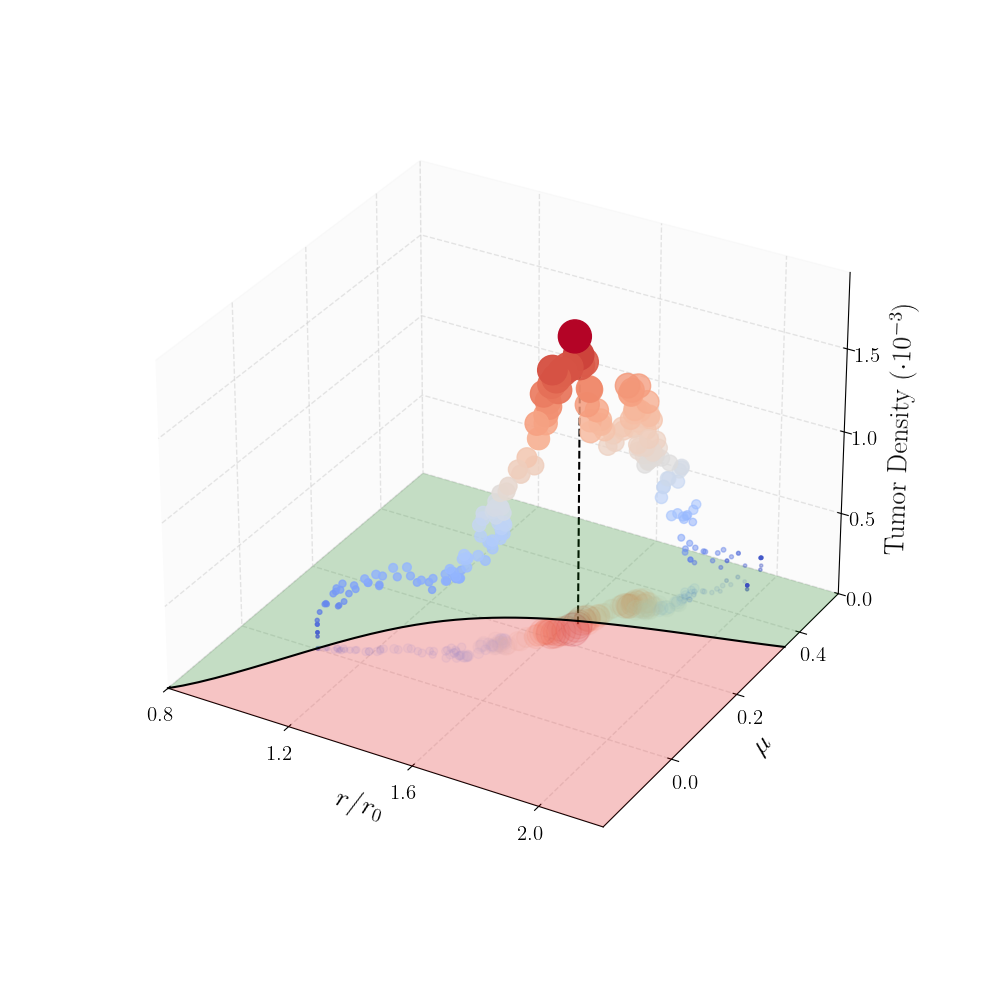

In [29]:


# Generate example trajectory
time = np.linspace(0, 10, len(rs_h))
x = points_h.T[0]
y = points_h.T[1]
z = t_h
size = np.power(t_h*10000, 2.2)+5


# Example data
z_min = 0  # where the phase diagram will live

y_spline = spl(x_new)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# ---- 3D trajectory (example) ----
ax.scatter(x, y, z, c=z, cmap='coolwarm', s=size)

# ---- Phase diagram on XY plane ----

# 1) Plot spline curve on XY plane
ax.plot(x_new, y_spline, zs=z_min, zdir='z', color='k', zorder=10)

# 2) Green region (above curve)
verts_green = [
    list(zip(x_new, y_spline)) +
    list(zip(x_new[::-1], np.full_like(x_new, max(y_spline)*1.5)))
]
poly_green = Poly3DCollection(
    [[(x, y, z_min) for x, y in verts_green[0]]],
    alpha=0.2,
    facecolor='green'
)
ax.add_collection3d(poly_green)

# 3) Red region (below curve)
verts_red = [
    list(zip(x_new, np.full_like(x_new, min(y_spline)))) +
    list(zip(x_new[::-1], np.full_like(x_new, y_spline[::-1])))
]
poly_red = Poly3DCollection(
    [[(x, y, z_min) for x, y in verts_red[0]]],
    alpha=0.2,
    facecolor='red'
)
ax.add_collection3d(poly_red)


ax.scatter(
    x, y,
    zs=0,
    zdir='z',
    c=z,
    cmap='coolwarm',
    s=size,
    alpha=0.1
)
# get crossing point between trajectory and phase diagram and draw vertical line
crossing_idx = np.where(np.diff(np.sign(points_h[:,1] - spl(points_h[:,0]))))[0][0]


# put vertical lines from points to plane
xi = x[crossing_idx]
yi = y[crossing_idx]
zi = z[crossing_idx]
ax.plot([xi, xi], [yi, yi], [0, zi], color='k', alpha=1, ls="--")

# Labels
ax.set_xlabel("$r/r_0$", fontsize=20, rotation=90, labelpad=10)
#same bound of the colored regions for x and y
ax.set_xlim([min(x_new), max(x_new)])
ax.set_xticks(np.arange(0.8,2.1,0.4))
ax.set_ylim([min(y_spline), max(y_spline)*1.5])
ax.set_yticks(np.arange(0,0.6,0.2))
ax.set_ylabel("$\mu$", fontsize=20, labelpad=10)
ax.set_zlabel("Tumor Density ($\cdot 10^{-3}$)", rotation=90, fontsize=20, labelpad=10)
ax.set_zlim([0, max(z)*1.1])
ax.set_zticks(np.arange(0,2e-3,5e-4), labels=np.arange(0,2,0.5))
ax.tick_params(axis='both', which='major', labelsize=15)
ax.zaxis.set_label_coords(105, 0.5)

# Change grid line properties for each axis
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"].update({
        'color': (0.8, 0.8, 0.8, 0.5),  # Light gray with 50% transparency
        'linewidth': 1,               # Thinner lines
        'linestyle': '--'               # Dashed lines
    })

ax.xaxis.set_pane_color((0.95, 0.95, 0.95, 0.3))
ax.yaxis.set_pane_color((0.95, 0.95, 0.95, 0.3))
#ax.zaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # 2 decimals
# adjust margins to make room for labels
ax.set_box_aspect(None, zoom=0.8) # For newer Matplotlib versions
# OR for older versions:
ax.dist = 0
plt.tight_layout()

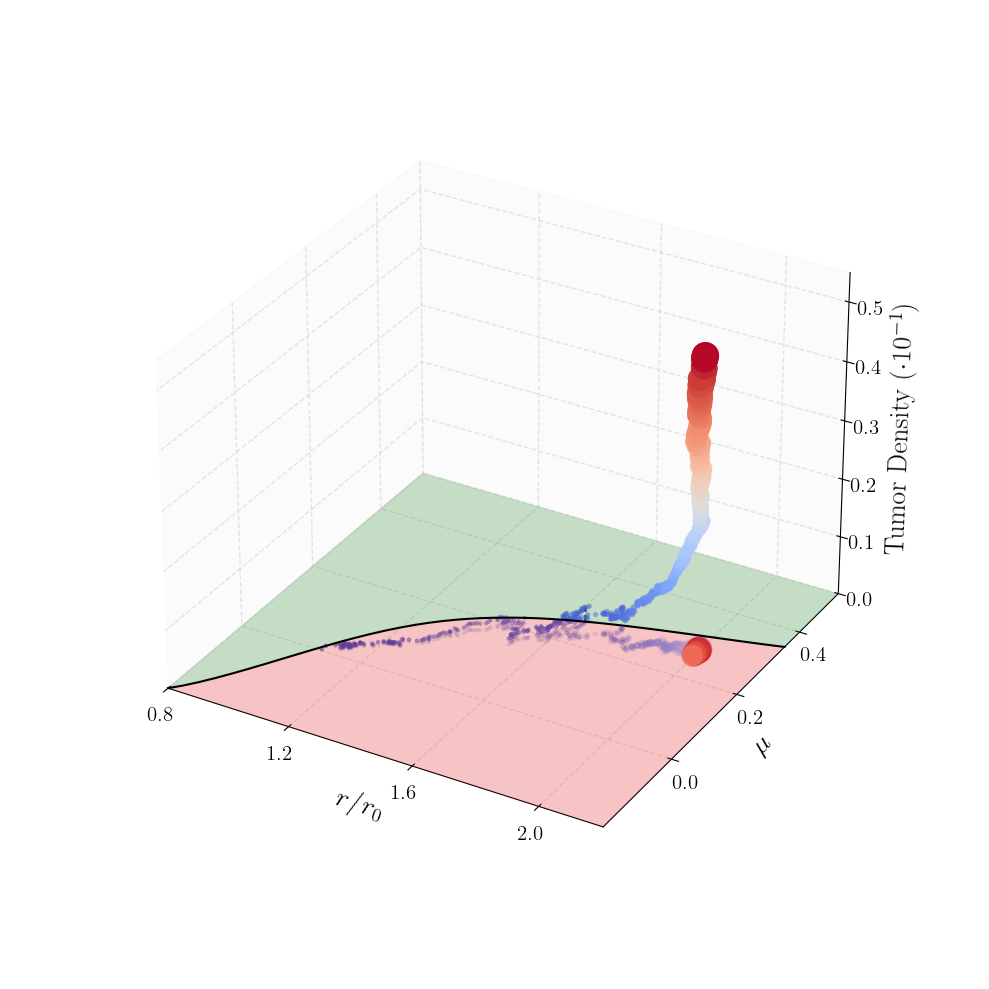

In [30]:


# Generate example trajectory
limm = 700
x = points_t.T[0][:limm]
y = points_t.T[1][:limm]
z = t_t[:limm]
size = np.power(t_t[:limm]*500, 1.8)+5


# Example data
z_min = 0  # where the phase diagram will live

y_spline = spl(x_new)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# ---- 3D trajectory (example) ----
ax.scatter(x, y, z, c=z, cmap='coolwarm', s=size)

# ---- Phase diagram on XY plane ----

# 1) Plot spline curve on XY plane
ax.plot(x_new, y_spline, zs=z_min, zdir='z', color='k', zorder=10)

# 2) Green region (above curve)
verts_green = [
    list(zip(x_new, y_spline)) +
    list(zip(x_new[::-1], np.full_like(x_new, max(y_spline)*1.5)))
]
poly_green = Poly3DCollection(
    [[(x, y, z_min) for x, y in verts_green[0]]],
    alpha=0.2,
    facecolor='green'
)
ax.add_collection3d(poly_green)

# 3) Red region (below curve)
verts_red = [
    list(zip(x_new, np.full_like(x_new, min(y_spline)))) +
    list(zip(x_new[::-1], np.full_like(x_new, y_spline[::-1])))
]
poly_red = Poly3DCollection(
    [[(x, y, z_min) for x, y in verts_red[0]]],
    alpha=0.2,
    facecolor='red'
)
ax.add_collection3d(poly_red)


ax.scatter(
    x, y,
    zs=0,
    zdir='z',
    c=z,
    cmap='coolwarm',
    s=size,
    alpha=0.1
)
# get crossing point between trajectory and phase diagram and draw vertical line
crossing_idx = np.where(np.diff(np.sign(points_t[:,1] - spl(points_t[:,0]))))[0][0]


# put vertical lines from points to plane
xi = x[crossing_idx]
yi = y[crossing_idx]
zi = z[crossing_idx]
ax.plot([xi, xi], [yi, yi], [0, zi], color='k', alpha=1, ls="--")

# Labels
ax.set_xlabel("$r/r_0$", fontsize=20, rotation=90, labelpad=10)
#same bound of the colored regions for x and y
ax.set_xlim([min(x_new), max(x_new)])
ax.set_xticks(np.arange(0.8,2.1,0.4))
ax.set_ylim([min(y_spline), max(y_spline)*1.5])
ax.set_yticks(np.arange(0,0.6,0.2))
ax.set_ylabel("$\mu$", fontsize=20, labelpad=10)
ax.set_zlabel("Tumor Density ($\cdot 10^{-1}$)", rotation=90, fontsize=20, labelpad=10)
ax.set_zlim([0, max(z)*1.1])
ax.set_zticks(np.arange(0, max(z)*1.1, 1e-2), labels=np.round(np.arange(0, max(z)*12, 0.100), 2))
ax.tick_params(axis='both', which='major', labelsize=15)
ax.zaxis.set_label_coords(105, 0.5)

# Change grid line properties for each axis
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"].update({
        'color': (0.8, 0.8, 0.8, 0.5),  # Light gray with 50% transparency
        'linewidth': 1,               # Thinner lines
        'linestyle': '--'               # Dashed lines
    })

ax.xaxis.set_pane_color((0.95, 0.95, 0.95, 0.3))
ax.yaxis.set_pane_color((0.95, 0.95, 0.95, 0.3))
#ax.zaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # 2 decimals
# adjust margins to make room for labels
ax.set_box_aspect(None, zoom=0.8) # For newer Matplotlib versions
# OR for older versions:
ax.dist = 0
plt.tight_layout()

# Interventions

In [56]:
int_mu, int_t, int_instant = {}, {}, {}
for int_type in ["A", "B", "C", "D"]:
    for metric in ["mu", "t", "timeint"]:
        data = np.loadtxt(f"../Data/CancerEvo/single/int_{int_type.lower()}_{metric}.txt")
        if metric == "mu":
            int_mu[int_type] = data
        elif metric == "t":
            int_t[int_type] = data
        else:
            int_instant[int_type] = data

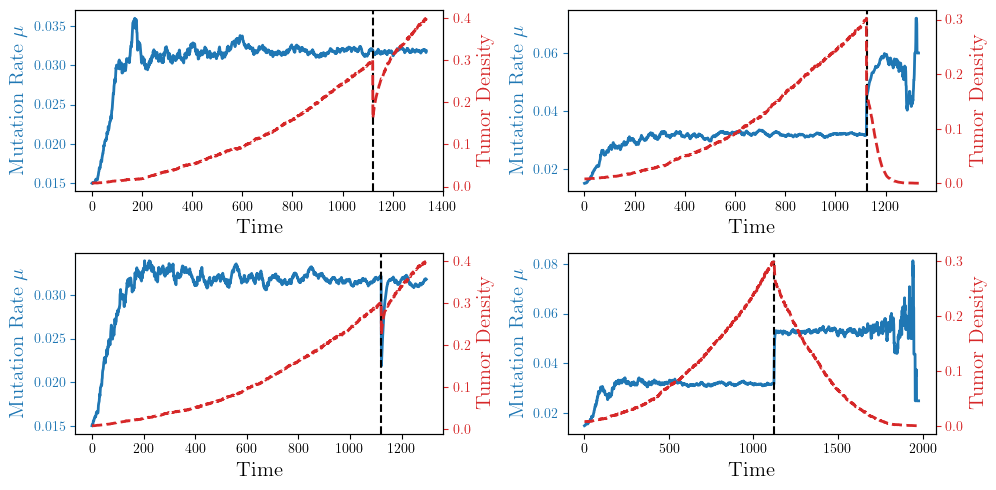

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax = ax.flatten()

for i, int_type in enumerate(["A", "B", "C", "D"]):

    # ---- Left axis ----
    ax[i].plot(int_mu[int_type], color="C0", lw=2)
    ax[i].set_xlabel("Time", fontsize=15)
    ax[i].axvline(int_instant[int_type], color="k", ls="--", lw=1.5, label="Intervention Time")

    ax[i].set_ylabel(r"Mutation Rate $\mu$", fontsize=15, color="C0")
    ax[i].tick_params(axis='y', colors="C0")
    ax[i].spines["left"].set_color("C0")

    #ax[i].grid(ls="--", lw=1, alpha=0.5)

    # ---- Right axis ----
    ax2 = ax[i].twinx()
    ax2.plot(int_t[int_type], color="C3", lw=2, ls="--")

    ax2.set_ylabel("Tumor Density", fontsize=15, color="C3")
    ax2.tick_params(axis='y', colors="C3")
    #ax2.spines["right"].set_color("C3")
# increase space between subplots

plt.tight_layout()


# IGNORE

## Gif

In [29]:
filenames = [f"aa{i}.png" for i in range(1000)]
# Create a GIF
with imageio.get_writer('gif/prog_pop_1.gif', mode='I', duration=0.5) as writer:
    for filename in filenames:
        image = imageio.v2.imread("../Data/CancerEvo/gif/"+filename)
        writer.append_data(image)

# Remove the image files for filename in filenames:
shutil.rmtree('../Data/CancerEvo/gif')